# 🏏 IPL Data Analysis — Exploratory Data Analysis (EDA)

**Internship Project | CodeAlpha | Data Analytics Domain**

In this notebook, I have done an Exploratory Data Analysis (EDA) on the IPL dataset.
The dataset covers IPL seasons from 2008 to 2020.
I used Python to clean the data, explore it and find useful insights.

## Step 1: Importing Required Libraries

I started by importing the libraries I need for analysis and visualization.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Loading the Dataset

I loaded two CSV files:
- **matches.csv** — has details of each IPL match like teams, toss, winner, venue
- **deliveries.csv** — has ball-by-ball data for every match

In [26]:
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

## Step 3: Checking the Shape of the Data

Let me see how many rows and columns are there in each dataset.

In [27]:
print("Matches Shape:", matches.shape)
print("Deliveries Shape:", deliveries.shape)

Matches Shape: (1095, 20)
Deliveries Shape: (260920, 17)


## Step 4: Exploring the Matches Dataset

I used head(), info() and columns to understand the structure of the data.

In [28]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [29]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [30]:
print(matches.columns)

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')


## Step 5: Checking for Missing Values

Before analysis, I checked if any columns have missing values.
This helps to avoid errors during analysis.

In [31]:
#Missing Values
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

**What I found:**
- `winner` column has 5 missing values — these are matches with no result (rain, abandoned)
- `method` column has many nulls — it only gets filled when DLS method is used
- `city` has some nulls but it won't affect our main analysis

## Step 6: Which Teams Won the Most Matches?

I wanted to find which IPL teams have been most successful overall.

In [32]:
#Successful Teams
matches['winner'].value_counts().head(10)

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Name: count, dtype: int64

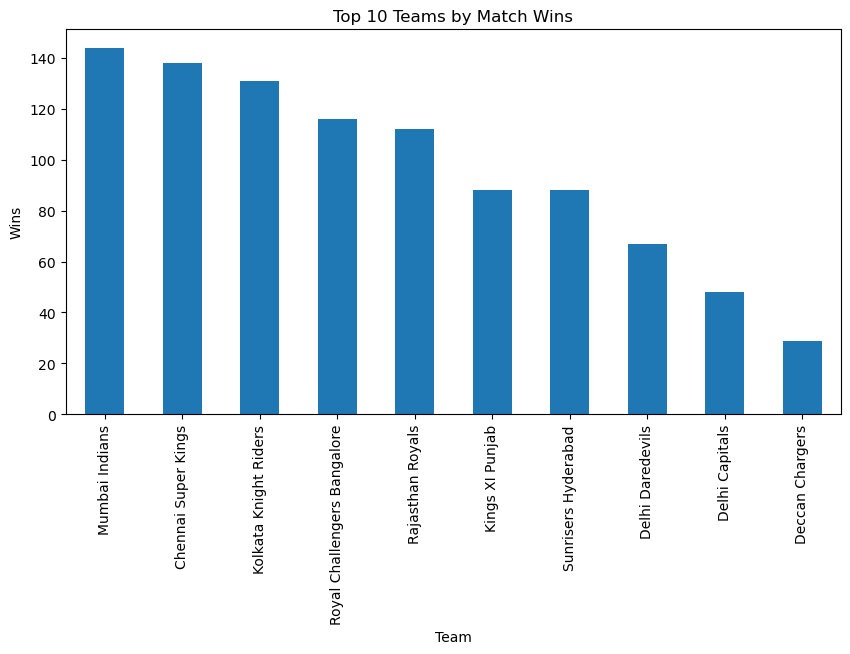

In [33]:
plt.figure(figsize=(10,5))

matches['winner'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Teams by Match Wins")
plt.xlabel("Team")
plt.ylabel("Wins")

plt.show()

**What I found:**
Mumbai Indians have the most wins in IPL history, followed by Chennai Super Kings.
These two teams have dominated IPL for most of the seasons.

## Step 7: Does Winning the Toss Help Win the Match?

I was curious whether toss plays a big role in deciding the match result.

In [34]:
#Toss Winner Impact
toss_win = (
    matches['toss_winner'] == matches['winner']
).mean()*100

print("Percentage:", toss_win)

Percentage: 50.593607305936075


**What I found:**
The toss winner wins around 50% of the time.
So toss alone does not decide who wins — team performance matters more.

## Step 8: Top 10 Player of the Match Winners

I wanted to see which players have won the most Man of the Match awards in IPL.

In [35]:
#Top Players
matches['player_of_match'].value_counts().head(10)

player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
DA Warner         18
V Kohli           18
MS Dhoni          17
SR Watson         16
YK Pathan         16
RA Jadeja         16
AD Russell        15
Name: count, dtype: int64

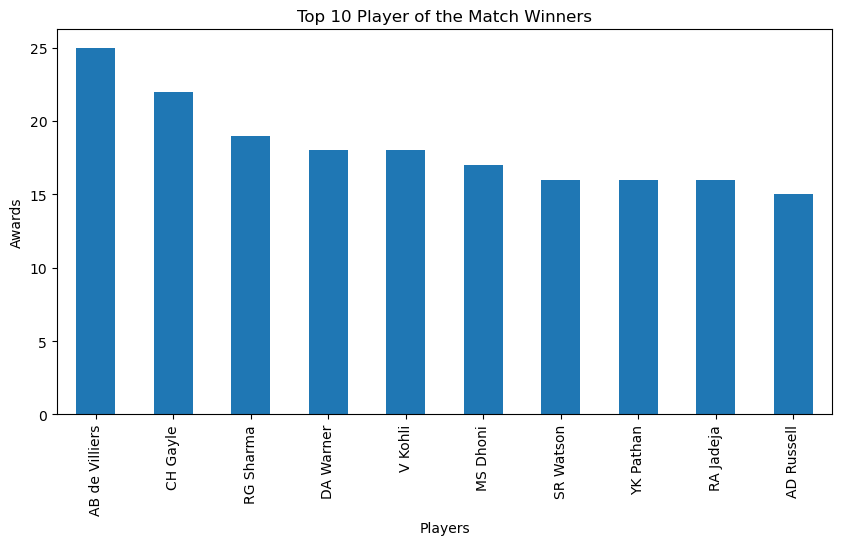

In [36]:
plt.figure(figsize=(10,5))

matches['player_of_match'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Player of the Match Winners")
plt.xlabel("Players")
plt.ylabel("Awards")

plt.show()

**What I found:**
Chris Gayle and AB de Villiers are among the top match winners in IPL.
These players have made a big impact in many matches across seasons.

## Step 9: Which Venues Have Hosted the Most Matches?

Let me find the stadiums that have hosted the most IPL matches.

In [37]:
#Top Venues
matches['venue'].value_counts().head(10)

venue
Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         65
Feroz Shah Kotla                              60
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Stadium, Chepauk               48
Sawai Mansingh Stadium                        47
Dubai International Cricket Stadium           46
Wankhede Stadium, Mumbai                      45
Punjab Cricket Association Stadium, Mohali    35
Name: count, dtype: int64

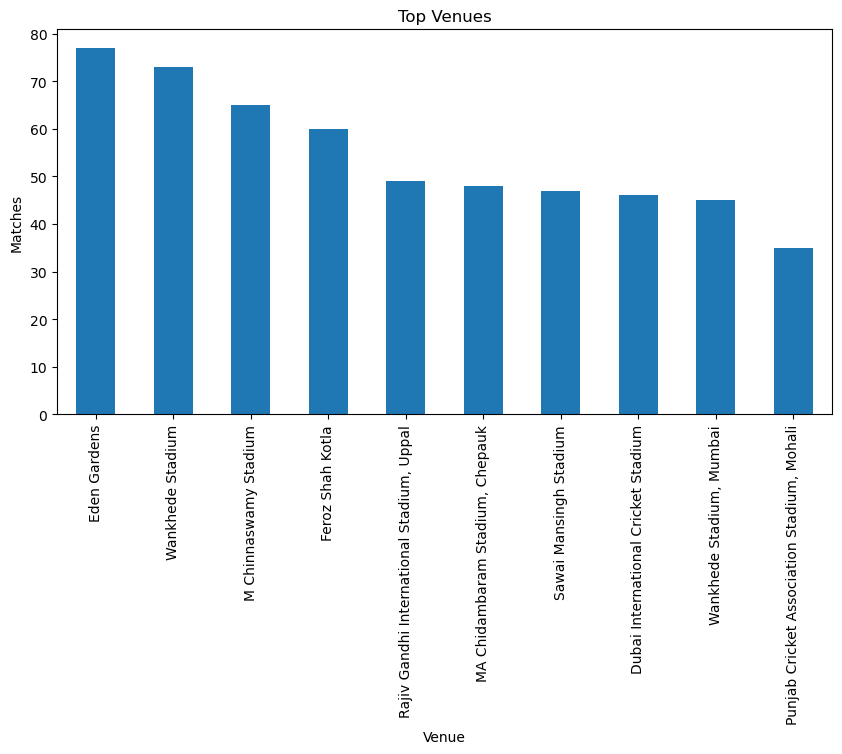

In [38]:
plt.figure(figsize=(10,5))

matches['venue'].value_counts().head(10).plot(kind='bar')

plt.title("Top Venues")
plt.xlabel("Venue")
plt.ylabel("Matches")

plt.show()

**What I found:**
Eden Gardens in Kolkata and Wankhede Stadium in Mumbai are the most popular IPL venues.
These are iconic cricket stadiums in India.

## Step 10: How Many Matches Were Played Each Season?

I checked how IPL grew over the years by looking at the number of matches per season.

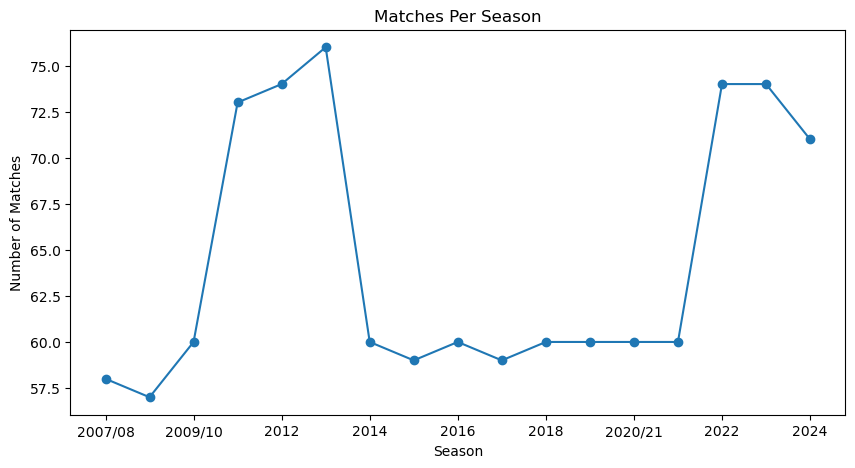

In [39]:
plt.figure(figsize=(10,5))

matches['season'].value_counts().sort_index().plot(marker='o')

plt.title("Matches Per Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")

plt.show()

**What I found:**
The number of matches has generally increased over the years.
In 2020, IPL was held in UAE because of COVID-19, but it still had a full season.

## Step 11: What Do Teams Choose After Winning the Toss?

Let me see whether teams prefer to bat or field first after winning the toss.

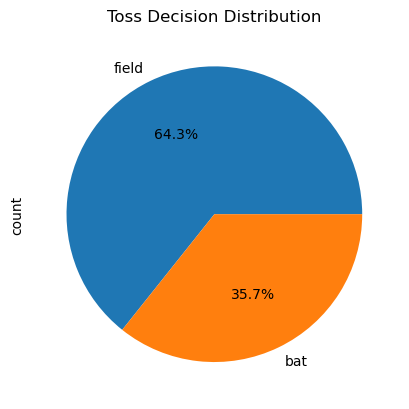

In [40]:
matches['toss_decision'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Toss Decision Distribution")
plt.show()

**What I found:**
Most captains choose to field first after winning the toss.
In T20, chasing is easier because you know the exact target to reach.

## Step 12: Top 10 Run Scorers in IPL History

Now I used the deliveries dataset to find the batsmen who scored the most runs overall.

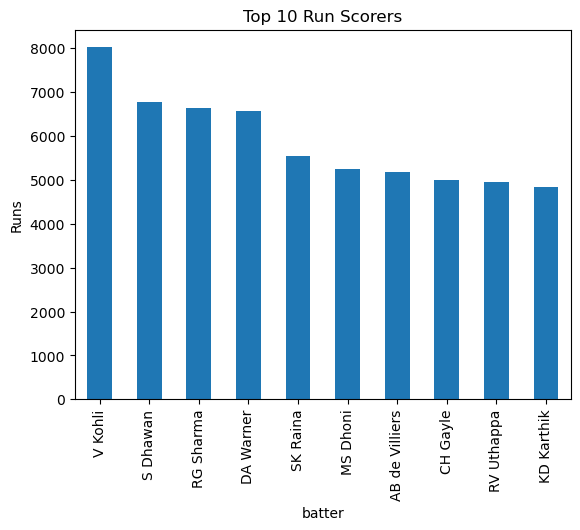

In [41]:
top_batsmen = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

top_batsmen.plot(kind='bar')
plt.title("Top 10 Run Scorers")
plt.ylabel("Runs")
plt.show()

**What I found:**
Virat Kohli is the highest run scorer in IPL history.
Suresh Raina and David Warner are also in the top scorers list.

## Step 13: Top 10 Wicket Takers in IPL History

Let me also find which bowlers have taken the most wickets in IPL.

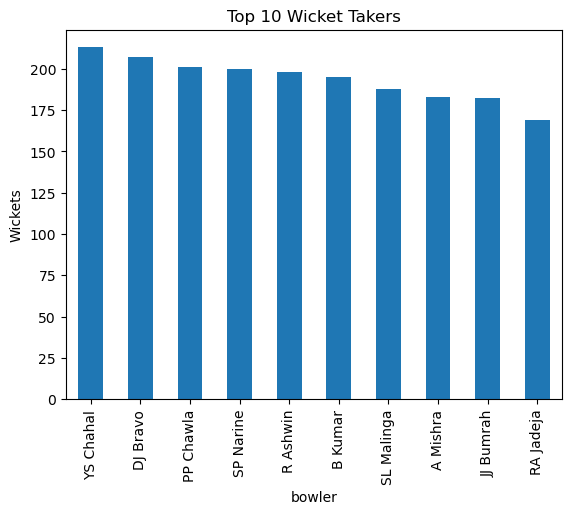

In [42]:
wickets = deliveries[
    deliveries['player_dismissed'].notna()
]

top_bowlers = wickets.groupby('bowler')['player_dismissed'].count().sort_values(ascending=False).head(10)

top_bowlers.plot(kind='bar')
plt.title("Top 10 Wicket Takers")
plt.ylabel("Wickets")
plt.show()

**What I found:**
Lasith Malinga is the highest wicket taker in IPL history.
He was famous for his yorkers and has been very difficult to hit in the death overs.

## Step 14: Total Runs Scored Each Season

Finally, I wanted to see how the total runs scored across all IPL matches has changed each season.

In [43]:
season_runs = deliveries.merge(
    matches[['id','season']], 
    left_on='match_id', 
    right_on='id'
)

In [44]:
season_runs.groupby('season')['total_runs'].sum()

season
2007/08    17937
2009       16353
2009/10    18883
2011       21154
2012       22453
2013       22602
2014       18931
2015       18353
2016       18862
2017       18786
2018       19901
2019       19434
2020/21    19416
2021       18637
2022       24395
2023       25688
2024       25971
Name: total_runs, dtype: int64

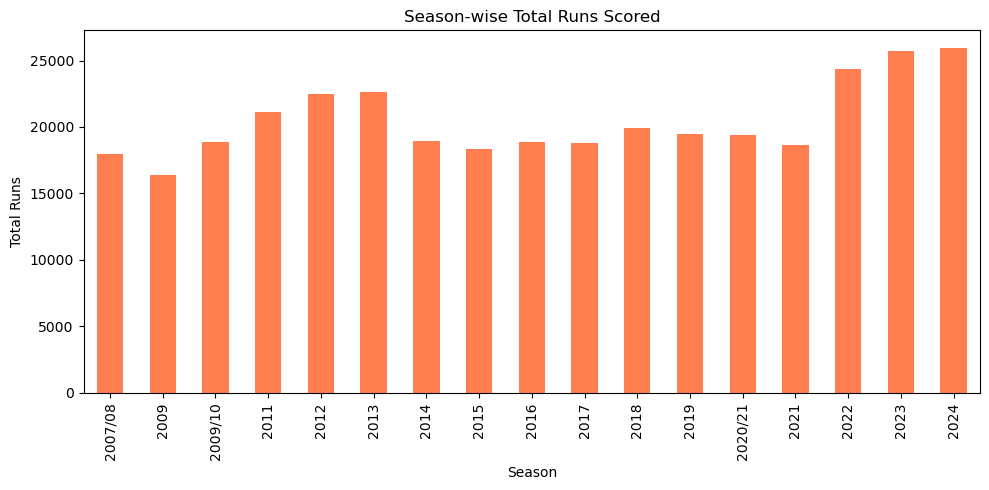

In [45]:
season_runs.groupby('season')['total_runs'].sum().plot(
    kind='bar', figsize=(10,5), color='coral'
)
plt.title("Season-wise Total Runs Scored")
plt.xlabel("Season")
plt.ylabel("Total Runs")
plt.tight_layout()
plt.show()

**What I found:**
Total runs scored per season has been going up over the years.
This shows that batsmen have become more aggressive and the game has evolved a lot.

## Conclusion

In this EDA project, I analyzed the IPL dataset from 2008 to 2020 and found these key insights:

1. **Mumbai Indians** have won the most matches in IPL history
2. Winning the toss gives only about a **50% chance** of winning the match
3. Most captains prefer to **field first** after winning the toss
4. **Virat Kohli** is the highest run scorer in IPL
5. **Lasith Malinga** is the highest wicket taker in IPL
6. **Eden Gardens** has hosted the most IPL matches
7. Total runs per season has been increasing over time

This project helped me learn how to work with real-world sports data using Python, Pandas, Matplotlib and Seaborn.